# ViT + MLP Multimodal Pneumonia Prediction (v2)

**Data**
- Structured (EHR): `data/mimic_ed_cxr_pneumonia_multimodal_cohort.csv` (MIMIC-ED triage + chief complaints + CCI)
- Images (CXR): `data/files/p{XX}/p{subject_id}/s{study_id}/{dicom_id}.jpg` (MIMIC-CXR)
- Label Y: `Pneumonia` (extracted by CheXpert NLP on the CXR report)

**Pipeline**
1. Install / import packages (this cell)
2. Data normalization: StandardScaler for EHR, ImageNet mean/std for images
3. Late fusion: ViT (768-d) ⊕ MLP(64-d) → Linear → Sigmoid
4. Backbone comparison: timm `vit_base_patch16_224` vs HuggingFace `google/vit-base-patch16-224`
5. Inference: sigmoid probabilities, threshold 0.5
6. Evaluation: AUROC + AUPRC


## Step 1 — Install & import packages

Uncomment the `pip install` line on the first run; comment it out afterwards.

In [ ]:
# Uncomment the following line on first run to install dependencies (skip if already installed)
# !pip install -q torch torchvision timm transformers scikit-learn pandas numpy pillow matplotlib tqdm

In [2]:
# ---- Basics ----
import os
import random
import warnings
from pathlib import Path

# Mac (Apple Silicon): when an op isn't supported on MPS, automatically fall back to CPU
# so we don't crash with NotImplementedError mid-training.
# This env var MUST be set BEFORE `import torch` to take effect.
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ---- PyTorch ----
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

# ---- ViT backbones ----
# Option A: timm (ImageNet pretrained; first call to create_model(pretrained=True) downloads weights automatically)
import timm

# Option B: HuggingFace transformers (swap in a medical-domain fine-tune later, e.g.
#          google/vit-base-patch16-224 or the StanfordAIMI family). Load with AutoImageProcessor + AutoModel.
from transformers import AutoImageProcessor, AutoModel

# ---- Preprocessing & metrics ----
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,    # = AUPRC
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---- Device ----
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'torch         : {torch.__version__}')
print(f'timm          : {timm.__version__}')
import transformers, sklearn
print(f'transformers  : {transformers.__version__}')
print(f'sklearn       : {sklearn.__version__}')
print(f'pandas        : {pd.__version__}')
print(f'numpy         : {np.__version__}')
print(f'device        : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU           : {torch.cuda.get_device_name(0)}')
    print(f'CUDA          : {torch.version.cuda}')
elif DEVICE.type == 'mps':
    print('MPS fallback  :', os.environ.get('PYTORCH_ENABLE_MPS_FALLBACK'))
    print('GPU           : Apple Silicon (Metal)')

torch         : 2.11.0
timm          : 1.0.26
transformers  : 5.5.4
sklearn       : 1.7.2
pandas        : 2.3.3
numpy         : 2.3.5
device        : mps
MPS fallback  : 1
GPU           : Apple Silicon (Metal)


In [ ]:
# ---- Paths (based on your project layout) ----
# code/, data/, and results/ all live as siblings under the project root,
# so from code/ we go up one level to find them.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'code' else Path.cwd()
DATA_DIR     = PROJECT_ROOT / 'data'
IMG_ROOT     = DATA_DIR / 'files'
COHORT_CSV   = DATA_DIR / 'mimic_ed_cxr_pneumonia_multimodal_cohort.csv'
RESULTS_DIR  = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)     # auto-create if missing

assert DATA_DIR.exists(),   f'data directory not found: {DATA_DIR}'
assert IMG_ROOT.exists(),   f'image directory not found: {IMG_ROOT}'
assert COHORT_CSV.exists(), f'cohort CSV not found: {COHORT_CSV}'

print('PROJECT_ROOT :', PROJECT_ROOT)
print('DATA_DIR     :', DATA_DIR)
print('IMG_ROOT     :', IMG_ROOT)
print('COHORT_CSV   :', COHORT_CSV)
print('RESULTS_DIR  :', RESULTS_DIR)

# Quick sanity check
_df_peek = pd.read_csv(COHORT_CSV, nrows=3)
print('\ncohort first 3 rows:')
_df_peek


## Step 2 — Data normalization

**Structured (EHR)**
- Numeric columns: `SimpleImputer(median)` to fill missing → `StandardScaler` to zero-mean / unit-variance
- Binary / ordinal columns (0/1, acuity 1–5): `SimpleImputer(most_frequent)`, no scaling (already 0/1 or an ordinal level)
- **Fit on train only**; val / test only transform → prevents data leakage

**Images (CXR)**
- Train: Resize(256) → RandomCrop(224) → random horizontal flip → ToTensor → ImageNet mean/std
- Val / Test: Resize(224) → CenterCrop(224) → ToTensor → ImageNet mean/std
- ImageNet statistics `mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]` because ViT is pretrained on ImageNet

**Split**
- 70 / 15 / 15, stratified on `Pneumonia`, fixed seed

In [ ]:
# ---- 2.1 Load cohort + define feature columns ----
df = pd.read_csv(COHORT_CSV)
print(f'cohort shape: {df.shape}')

LABEL_COL = 'Pneumonia'

# Numeric features (need StandardScaler)
NUMERIC_COLS = [
    'age',
    'triage_temperature',
    'triage_heartrate',
    'triage_resprate',
    'triage_o2sat',
    'triage_sbp',
    'triage_dbp',
    'score_CCI',
]

# Binary / ordinal categorical features (0/1 or 1-5), imputed only; no scaling
BINARY_COLS = [
    'gender',
    'triage_acuity',
    'chiefcom_shortness_of_breath',
    'chiefcom_cough',
    'chiefcom_fever_chills',
    'cci_Pulmonary',
    'cci_CHF',
]

TABULAR_COLS = NUMERIC_COLS + BINARY_COLS
TABULAR_DIM  = len(TABULAR_COLS)
print(f'total tabular features: {TABULAR_DIM}  (numeric={len(NUMERIC_COLS)}, binary={len(BINARY_COLS)})')

# Label distribution
print(f'\nlabel ({LABEL_COL}) distribution:')
print(df[LABEL_COL].value_counts(dropna=False))
print(f'positive rate: {df[LABEL_COL].mean():.3f}')

# Drop rows with missing label (if any)
before = len(df)
df = df.dropna(subset=[LABEL_COL]).reset_index(drop=True)
df[LABEL_COL] = df[LABEL_COL].astype(int)
print(f'after dropping missing labels: {before} → {len(df)}')

In [5]:
# ---- 2.2 Train / Val / Test stratified split (70 / 15 / 15) ----
# One row = one patient = one CXR, so no extra subject-level grouping needed

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df[LABEL_COL],
    random_state=SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,         # 0.15 / 0.30 = 0.50
    stratify=temp_df[LABEL_COL],
    random_state=SEED,
)

# Reset index so the Dataset can use iloc cleanly later
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

def _summarize(name, d):
    pos = d[LABEL_COL].mean()
    print(f'{name:<6}  n={len(d):>5}   pos_rate={pos:.3f}   pos={int(d[LABEL_COL].sum()):>4}   neg={int((1-d[LABEL_COL]).sum()):>4}')

_summarize('train', train_df)
_summarize('val',   val_df)
_summarize('test',  test_df)

train   n= 1120   pos_rate=0.328   pos= 367   neg= 753
val     n=  240   pos_rate=0.329   pos=  79   neg= 161
test    n=  241   pos_rate=0.328   pos=  79   neg= 162


In [ ]:
# ---- 2.3 EHR preprocessors: fit on train only ----
# Numeric columns: median imputer + StandardScaler
num_imputer = SimpleImputer(strategy='median')
scaler      = StandardScaler()

# Binary columns: most_frequent imputer, no scaling
bin_imputer = SimpleImputer(strategy='most_frequent')

# ---- fit on train ----
X_num_train = num_imputer.fit_transform(train_df[NUMERIC_COLS])
X_num_train = scaler.fit_transform(X_num_train)
X_bin_train = bin_imputer.fit_transform(train_df[BINARY_COLS])

# ---- transform val / test ----
def transform_tabular(dframe):
    X_num = num_imputer.transform(dframe[NUMERIC_COLS])
    X_num = scaler.transform(X_num)
    X_bin = bin_imputer.transform(dframe[BINARY_COLS])
    return np.concatenate([X_num, X_bin], axis=1).astype(np.float32)

X_tab_train = np.concatenate([X_num_train, X_bin_train], axis=1).astype(np.float32)
X_tab_val   = transform_tabular(val_df)
X_tab_test  = transform_tabular(test_df)

print(f'X_tab_train: {X_tab_train.shape}  dtype={X_tab_train.dtype}')
print(f'X_tab_val  : {X_tab_val.shape}')
print(f'X_tab_test : {X_tab_test.shape}')

# Sanity: numeric block should be ~0 mean / ~1 std on train
print('\nnumeric columns after standardization (train):')
print('  mean:', np.round(X_tab_train[:, :len(NUMERIC_COLS)].mean(axis=0), 3))
print('  std :', np.round(X_tab_train[:, :len(NUMERIC_COLS)].std(axis=0),  3))

# Label tensors
y_train = train_df[LABEL_COL].values.astype(np.float32)
y_val   = val_df[LABEL_COL].values.astype(np.float32)
y_test  = test_df[LABEL_COL].values.astype(np.float32)

In [ ]:
# ---- 2.4 Image transforms (ImageNet statistics) ----
IMG_SIZE   = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Train: light augmentation (horizontal flip is debated for CXR but usually fine on AP views)
train_tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Val / Test: no augmentation, just resize + center crop
eval_tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Peek at a transformed image's shape
def build_image_path(row):
    sid = int(row['subject_id'])
    sty = int(row['study_id'])
    did = row['dicom_id']
    prefix = f'p{str(sid)[:2]}'          # e.g. 10003019 -> p10
    return IMG_ROOT / prefix / f'p{sid}' / f's{sty}' / f'{did}.jpg'

_sample_row  = train_df.iloc[0]
_sample_path = build_image_path(_sample_row)
print('sample image path:', _sample_path)
print('exists:', _sample_path.exists())

_img = Image.open(_sample_path).convert('RGB')
_t   = eval_tfm(_img)
print(f'original size: {_img.size}  →  tensor after transform: {tuple(_t.shape)}  dtype={_t.dtype}')
print(f'tensor range: [{_t.min():.3f}, {_t.max():.3f}]  (mixed negative/positive values after normalization)')

In [ ]:
# ---- 2.5 (optional) Scan every image path for existence, to avoid FileNotFoundError mid-training ----
missing = []
for d in (train_df, val_df, test_df):
    for _, r in d.iterrows():
        p = build_image_path(r)
        if not p.exists():
            missing.append(str(p))

print(f'total rows: {len(train_df)+len(val_df)+len(test_df)}')
print(f'missing images: {len(missing)}')
if missing[:5]:
    print('first 5 missing:')
    for m in missing[:5]:
        print('  ', m)

## Step 3 — Dataset + Late Fusion model

**Dataset**
- `__getitem__` returns `(img_tensor, tab_tensor, label)`
- Images are read and transformed on the fly; tabular features are the numpy array already preprocessed in Step 2, converted to tensor

**Model architecture (Late Fusion)**

```
    CXR (3, 224, 224)                 Tabular (15,)
         │                                 │
         ▼                                 ▼
      ViT backbone                  TabularMLP
         │                                 │
      768-d feat                      64-d feat
         └──────── concat ─────────────────┘
                       │
                   832-d fused
                       │
                FC(832→128)→ReLU→Dropout
                       │
                    FC(128→1)
                       │
                   raw logit  (train: BCEWithLogitsLoss; inference: sigmoid → probability)
```

**Key design choices**
- Output is a raw logit, and `BCEWithLogitsLoss` uses its own log-sum-exp for numerical stability
- Preprocessors are shared between train and inference (Step 2 already fit on train only) → no leakage
- Class imbalance (~33% positive) is handled with `pos_weight`, not by resampling

In [9]:
# ---- 3.1 Dataset ----
class MIMICMultimodalDataset(Dataset):
    """
    Returns (image_tensor, tabular_tensor, label).
    - dataframe:  rows correspond to samples; used to build image paths
    - tabular_np: (N, TABULAR_DIM) already-standardized numpy array
    - labels_np:  (N,) float32, 0/1
    """
    def __init__(self, dataframe, tabular_np, labels_np,
                 img_root, transform, build_path_fn):
        assert len(dataframe) == len(tabular_np) == len(labels_np)
        self.df        = dataframe.reset_index(drop=True)
        self.tab       = torch.from_numpy(tabular_np)           # float32 tensor
        self.y         = torch.from_numpy(labels_np)            # float32 tensor
        self.img_root  = img_root
        self.transform = transform
        self.build_path = build_path_fn

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.build_path(row)
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        return img, self.tab[idx], self.y[idx]


# Instantiate the three datasets
train_ds = MIMICMultimodalDataset(train_df, X_tab_train, y_train, IMG_ROOT, train_tfm, build_image_path)
val_ds   = MIMICMultimodalDataset(val_df,   X_tab_val,   y_val,   IMG_ROOT, eval_tfm,  build_image_path)
test_ds  = MIMICMultimodalDataset(test_df,  X_tab_test,  y_test,  IMG_ROOT, eval_tfm,  build_image_path)

print(f'train_ds: {len(train_ds)}    val_ds: {len(val_ds)}    test_ds: {len(test_ds)}')

# Pull one sample and check shapes
_img, _tab, _lab = train_ds[0]
print(f'sample  img: {tuple(_img.shape)}  tab: {tuple(_tab.shape)}  label: {_lab.item()}')

train_ds: 1120    val_ds: 240    test_ds: 241
sample  img: (3, 224, 224)  tab: (15,)  label: 0.0


In [ ]:
# ---- 3.2 DataLoader ----
# On Mac + MPS, num_workers > 0 can occasionally hang, so we default to 0; on Linux/CUDA you can raise it to 4
BATCH_SIZE  = 32
NUM_WORKERS = 0

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))

# Pull one batch and take a look
_img_b, _tab_b, _lab_b = next(iter(train_loader))
print(f'batch img: {tuple(_img_b.shape)}   tab: {tuple(_tab_b.shape)}   lab: {tuple(_lab_b.shape)}')
print(f'positives in batch: {int(_lab_b.sum().item())}/{len(_lab_b)}')

In [ ]:
# ---- 3.3 Model definitions: TabularMLP + MultimodalViTClassifier ----

class TabularMLP(nn.Module):
    """Structured features -> intermediate feature vector."""
    def __init__(self, in_dim, out_dim=64, hidden=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class MultimodalViTClassifier(nn.Module):
    """
    Late fusion:
        image -> vit_backbone -> (B, vit_feat_dim)
        tab   -> TabularMLP    -> (B, tab_out_dim)
        concat -> MLP head     -> (B,) raw logit
    vit_backbone must be an nn.Module that takes (B,3,224,224) and returns (B, vit_feat_dim).
    Step 4 provides two interchangeable options (timm / HF) that plug in here.
    """
    def __init__(self, vit_backbone, vit_feat_dim,
                 tab_in_dim, tab_out_dim=64, head_hidden=128, dropout=0.2):
        super().__init__()
        self.vit  = vit_backbone
        self.mlp  = TabularMLP(tab_in_dim, out_dim=tab_out_dim, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(vit_feat_dim + tab_out_dim, head_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, 1),
        )
        self.vit_feat_dim = vit_feat_dim
        self.tab_out_dim  = tab_out_dim

    def forward(self, img, tab):
        img_feat = self.vit(img)                      # (B, vit_feat_dim)
        tab_feat = self.mlp(tab)                      # (B, tab_out_dim)
        fused    = torch.cat([img_feat, tab_feat], dim=1)
        logit    = self.head(fused).squeeze(-1)       # (B,)
        return logit

    @torch.no_grad()
    def predict_proba(self, img, tab):
        """For inference: returns sigmoid pneumonia probabilities with shape (B,), range [0, 1]."""
        self.eval()
        return torch.sigmoid(self.forward(img, tab))

print('model classes defined: TabularMLP + MultimodalViTClassifier')

In [ ]:
# ---- 3.4 Smoke test: run a forward pass with a randomly initialized ViT ----
# Here we only verify shapes line up; no pretrained weights downloaded (pretrained=False, fast)
# Step 4 will switch to the real pretrained version

_tiny_vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=0)
# num_classes=0 tells timm to drop the classification head and return the pooled feature directly (768-d)
_vit_feat_dim = _tiny_vit.num_features   # = 768 for vit_base
print(f'ViT output dim (num_features): {_vit_feat_dim}')

_model = MultimodalViTClassifier(
    vit_backbone = _tiny_vit,
    vit_feat_dim = _vit_feat_dim,
    tab_in_dim   = TABULAR_DIM,
    tab_out_dim  = 64,
).to(DEVICE)

# Parameter counts
_n_total   = sum(p.numel() for p in _model.parameters())
_n_train   = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f'params: total={_n_total/1e6:.2f}M   trainable={_n_train/1e6:.2f}M')

# Run a small batch through
_img_b = _img_b.to(DEVICE)
_tab_b = _tab_b.to(DEVICE)
_lab_b = _lab_b.to(DEVICE)

_logits = _model(_img_b, _tab_b)
print(f'logits shape: {tuple(_logits.shape)}     dtype: {_logits.dtype}     device: {_logits.device}')
print(f'logits sample: {_logits[:5].detach().cpu().numpy()}')

# BCEWithLogitsLoss takes logits + 0/1 labels directly
_loss_fn = nn.BCEWithLogitsLoss()
_loss = _loss_fn(_logits, _lab_b)
print(f'loss (untrained): {_loss.item():.4f}    (≈ ln(2) ≈ 0.693 is a reasonable starting point)')

# Backward pass test
_loss.backward()
print('backward pass OK ✓')

# Cleanup
del _model, _tiny_vit, _loss, _logits
import gc; gc.collect()
if DEVICE.type == 'mps':
    torch.mps.empty_cache()
elif DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
print('smoke test done, memory cleared')

## Step 4 — Backbone factory: timm ↔ HuggingFace

**Goal**: a single `build_vit(backend=...)` function so we can swap between timm and HuggingFace, while the `MultimodalViTClassifier` from Step 3 stays exactly the same.

**Why does the factory also return mean/std?**
- timm `vit_base_patch16_224` defaults to `mean/std = (0.5, 0.5, 0.5)` (original ViT/JFT recipe)
- HF `google/vit-base-patch16-224` also defaults to `mean/std = (0.5, 0.5, 0.5)`
- Both differ from the ImageNet `(0.485, 0.456, 0.406)` we used in Step 2
- The wrong mean/std shifts the distribution the pretrained weights expect and costs some performance

So the factory returns `(backbone, feat_dim, mean, std)` and we rebuild the transforms + Datasets + DataLoaders using the returned mean/std.

**First-time downloads**
- timm pretrained weights ≈ 340 MB, cached under `~/.cache/torch/hub/` or `~/.cache/huggingface/`
- HF model ≈ 340 MB, cached under `~/.cache/huggingface/`
- Subsequent loads read from cache and are fast

In [ ]:
# ---- 4.1 HF wrapper + unified backbone factory ----

class HFViTWrapper(nn.Module):
    """
    Wraps a HuggingFace ViTModel so it exposes the same interface as timm:
      input  : (B, 3, H, W) pixel_values (already normalized)
      output : (B, hidden_size) feature vector
    Uses pooler_output if available, otherwise the [CLS] token from last_hidden_state.
    """
    def __init__(self, hf_model):
        super().__init__()
        self.vit = hf_model
        self.hidden_size = hf_model.config.hidden_size

    def forward(self, pixel_values):
        out = self.vit(pixel_values=pixel_values)
        if getattr(out, 'pooler_output', None) is not None:
            return out.pooler_output                  # (B, hidden_size)
        return out.last_hidden_state[:, 0, :]         # CLS token


def build_vit(backend='timm', model_name=None, pretrained=True):
    """
    Returns: (backbone_module, feat_dim, mean, std)
      backend   : 'timm' or 'hf'
      model_name: default 'vit_base_patch16_224' (timm) or 'google/vit-base-patch16-224' (hf)
    """
    assert backend in ('timm', 'hf'), f'unknown backend: {backend}'

    if backend == 'timm':
        name = model_name or 'vit_base_patch16_224'
        model = timm.create_model(name, pretrained=pretrained, num_classes=0)
        feat_dim = model.num_features
        cfg = getattr(model, 'default_cfg', {}) or {}
        mean = tuple(cfg.get('mean', (0.5, 0.5, 0.5)))
        std  = tuple(cfg.get('std',  (0.5, 0.5, 0.5)))
        return model, feat_dim, mean, std

    # backend == 'hf'
    name = model_name or 'google/vit-base-patch16-224'
    # The processor is only used to read mean/std; the actual preprocessing is still done with torchvision transforms
    processor = AutoImageProcessor.from_pretrained(name)
    mean = tuple(processor.image_mean)
    std  = tuple(processor.image_std)
    hf_model = AutoModel.from_pretrained(name)
    wrapper  = HFViTWrapper(hf_model)
    return wrapper, wrapper.hidden_size, mean, std


def make_transforms(mean, std, img_size=224):
    """Rebuild train / eval transforms using the given mean/std."""
    train_tfm_ = transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(img_size),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=list(mean), std=list(std)),
    ])
    eval_tfm_ = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=list(mean), std=list(std)),
    ])
    return train_tfm_, eval_tfm_

print('build_vit / make_transforms ready ✓')

In [14]:
# ---- 4.2 Smoke test: timm backbone (first run downloads ≈ 340 MB) ----
_bk_timm, _d_timm, _m_timm, _s_timm = build_vit(backend='timm', pretrained=True)
print(f'[timm]  feat_dim={_d_timm}   mean={_m_timm}   std={_s_timm}')

# Run a random tensor through forward to verify
with torch.no_grad():
    _x = torch.randn(2, 3, 224, 224)
    _feat = _bk_timm(_x)
print(f'[timm] forward shape: {tuple(_feat.shape)}  expect (2, {_d_timm})')

del _bk_timm, _feat, _x
import gc; gc.collect()

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

[timm]  feat_dim=768   mean=(0.5, 0.5, 0.5)   std=(0.5, 0.5, 0.5)
[timm] forward shape: (2, 768)  expect (2, 768)


192

In [15]:
# ---- 4.3 Smoke test: HF backbone (first run downloads ≈ 340 MB) ----
_bk_hf, _d_hf, _m_hf, _s_hf = build_vit(backend='hf', pretrained=True)
print(f'[hf]    feat_dim={_d_hf}   mean={_m_hf}   std={_s_hf}')

with torch.no_grad():
    _x = torch.randn(2, 3, 224, 224)
    _feat = _bk_hf(_x)
print(f'[hf]   forward shape: {tuple(_feat.shape)}  expect (2, {_d_hf})')

del _bk_hf, _feat, _x
import gc; gc.collect()

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[hf]    feat_dim=768   mean=(0.5, 0.5, 0.5)   std=(0.5, 0.5, 0.5)
[hf]   forward shape: (2, 768)  expect (2, 768)


1621

In [ ]:
# ---- 4.4 Pick a backend, rebuild transforms + Dataset + DataLoader with its mean/std ----
# To switch backbones, change only this line ('timm' or 'hf') and rerun this cell.
BACKEND     = 'timm'
MODEL_NAME  = None          # None = use default ('vit_base_patch16_224' / 'google/vit-base-patch16-224')

backbone, VIT_FEAT_DIM, IMG_MEAN, IMG_STD = build_vit(backend=BACKEND, model_name=MODEL_NAME, pretrained=True)
print(f'selected backend: {BACKEND}')
print(f'VIT_FEAT_DIM: {VIT_FEAT_DIM}')
print(f'IMG_MEAN    : {IMG_MEAN}')
print(f'IMG_STD     : {IMG_STD}')

# Rebuild transforms with the new mean/std
train_tfm, eval_tfm = make_transforms(IMG_MEAN, IMG_STD, img_size=IMG_SIZE)

# Rebuild Datasets + DataLoaders (overwrites the ones from Step 3)
train_ds = MIMICMultimodalDataset(train_df, X_tab_train, y_train, IMG_ROOT, train_tfm, build_image_path)
val_ds   = MIMICMultimodalDataset(val_df,   X_tab_val,   y_val,   IMG_ROOT, eval_tfm,  build_image_path)
test_ds  = MIMICMultimodalDataset(test_df,  X_tab_test,  y_test,  IMG_ROOT, eval_tfm,  build_image_path)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))

# Assemble the final model
model = MultimodalViTClassifier(
    vit_backbone = backbone,
    vit_feat_dim = VIT_FEAT_DIM,
    tab_in_dim   = TABULAR_DIM,
    tab_out_dim  = 64,
).to(DEVICE)

_n_total = sum(p.numel() for p in model.parameters())
_n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'model params: total={_n_total/1e6:.2f}M   trainable={_n_train/1e6:.2f}M   device={DEVICE}')

# Run one real batch to verify (with pretrained weights the loss won't be ≈ ln(2), but the shape must match)
_img_b, _tab_b, _lab_b = next(iter(train_loader))
_img_b = _img_b.to(DEVICE); _tab_b = _tab_b.to(DEVICE); _lab_b = _lab_b.to(DEVICE)
with torch.no_grad():
    _logits = model(_img_b, _tab_b)
    _probs  = torch.sigmoid(_logits)
print(f'logits shape: {tuple(_logits.shape)}   probs range: [{_probs.min():.3f}, {_probs.max():.3f}]')

## Step 5 — Training & inference

**Loss**: `BCEWithLogitsLoss(pos_weight = neg/pos)` handles class imbalance (~33% positive)

**Optimizer**: AdamW with parameter groups
- ViT backbone: `lr = 1e-5` (fine-tuning; too large and the pretrained weights get wrecked)
- MLP + fusion head: `lr = 1e-3` (trained from scratch; needs to learn faster)
- Weight decay 1e-2 (excluding LayerNorm / bias)

**Scheduler**: CosineAnnealingLR, T_max = EPOCHS

**Training strategy**
- Each epoch logs train/val loss + val AUROC
- Keep the checkpoint with the best val AUROC, save to `vit_v2_best.pt`
- Run inference on test; save probs + labels to `test_predictions` for Step 6 to evaluate

**First-run runtime estimate** (M5 Pro MPS, 10 epochs)
- Training ≈ 2–4 min per epoch, validation ≈ 30 s
- Total ≈ 25–40 minutes

If it's too slow to test end-to-end, run `EPOCHS = 2` first to smoke-test the pipeline, then scale up.

In [ ]:
# ---- 5.1 Hyperparameters + loss + optimizer + scheduler ----
EPOCHS          = 10
LR_BACKBONE     = 1e-5
LR_HEAD         = 1e-3
WEIGHT_DECAY    = 1e-2
CKPT_PATH       = RESULTS_DIR / 'vit_v2_best.pt'

# pos_weight = (#negatives) / (#positives), computed on train only
n_pos = int(y_train.sum())
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32, device=DEVICE)
print(f'train: pos={n_pos}   neg={n_neg}   pos_weight={pos_weight.item():.3f}')

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Parameter groups: backbone vs (mlp + head)
backbone_params = list(model.vit.parameters())
head_params     = list(model.mlp.parameters()) + list(model.head.parameters())

# Exclude LayerNorm / bias params from weight decay
def split_wd(params):
    decay, no_decay = [], []
    for p in params:
        if not p.requires_grad:
            continue
        if p.ndim <= 1:     # both biases and LayerNorm params are 1D
            no_decay.append(p)
        else:
            decay.append(p)
    return decay, no_decay

bb_decay, bb_nodecay = split_wd(backbone_params)
hd_decay, hd_nodecay = split_wd(head_params)

optimizer = torch.optim.AdamW([
    {'params': bb_decay,   'lr': LR_BACKBONE, 'weight_decay': WEIGHT_DECAY},
    {'params': bb_nodecay, 'lr': LR_BACKBONE, 'weight_decay': 0.0},
    {'params': hd_decay,   'lr': LR_HEAD,     'weight_decay': WEIGHT_DECAY},
    {'params': hd_nodecay, 'lr': LR_HEAD,     'weight_decay': 0.0},
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f'EPOCHS={EPOCHS}, LR_backbone={LR_BACKBONE}, LR_head={LR_HEAD}, WD={WEIGHT_DECAY}')
print(f'checkpoint will be saved to: {CKPT_PATH}')


In [ ]:
# ---- 5.2 Training / evaluation helpers ----

def run_epoch(model, loader, loss_fn, optimizer=None, device=DEVICE, desc='train'):
    """optimizer=None -> evaluation mode. Returns (avg_loss, all_probs, all_labels)."""
    is_train = optimizer is not None
    model.train(is_train)

    total_loss, total_n = 0.0, 0
    all_probs, all_labels = [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for img, tab, y in tqdm(loader, desc=desc, leave=False):
            img = img.to(device, non_blocking=True)
            tab = tab.to(device, non_blocking=True)
            y   = y.to(device, non_blocking=True)

            logits = model(img, tab)
            loss   = loss_fn(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping to avoid exploding grads
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            bs = y.size(0)
            total_loss += loss.item() * bs
            total_n    += bs
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.append(y.detach().cpu().numpy())

    avg_loss = total_loss / max(total_n, 1)
    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return avg_loss, all_probs, all_labels


def quick_metrics(y_true, y_prob):
    """Compute AUROC + AUPRC quickly during training. sklearn errors out when all labels are one class, so guard."""
    try:
        auroc = roc_auc_score(y_true, y_prob)
    except Exception:
        auroc = float('nan')
    try:
        auprc = average_precision_score(y_true, y_prob)
    except Exception:
        auprc = float('nan')
    return auroc, auprc

print('run_epoch / quick_metrics ready ✓')

In [ ]:
# ---- 5.3 Training loop ----
import time, copy

history = {'train_loss': [], 'val_loss': [], 'val_auroc': [], 'val_auprc': []}
best_auroc = -1.0
best_epoch = -1
best_state = None

print(f'training start: {EPOCHS} epochs, device={DEVICE}, backend={BACKEND}')
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    ep_start = time.time()

    tr_loss, _,  _        = run_epoch(model, train_loader, loss_fn, optimizer=optimizer, desc=f'ep{epoch} train')
    va_loss, va_p, va_y   = run_epoch(model, val_loader,   loss_fn, optimizer=None,      desc=f'ep{epoch} val  ')
    scheduler.step()

    va_auroc, va_auprc = quick_metrics(va_y, va_p)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['val_auroc'].append(va_auroc)
    history['val_auprc'].append(va_auprc)

    lr_bb = optimizer.param_groups[0]['lr']
    lr_hd = optimizer.param_groups[2]['lr']
    print(f'[ep {epoch:02d}] train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}  '
          f'val_AUROC={va_auroc:.4f}  val_AUPRC={va_auprc:.4f}  '
          f'lr(bb)={lr_bb:.2e}  lr(hd)={lr_hd:.2e}  time={time.time()-ep_start:.1f}s')

    # Keep best checkpoint by val AUROC
    if va_auroc > best_auroc:
        best_auroc = va_auroc
        best_epoch = epoch
        best_state = copy.deepcopy({k: v.cpu() for k, v in model.state_dict().items()})
        torch.save({'state_dict': best_state,
                    'epoch': epoch,
                    'val_auroc': va_auroc,
                    'val_auprc': va_auprc,
                    'backend': BACKEND,
                    'img_mean': IMG_MEAN, 'img_std': IMG_STD,
                    'tabular_cols': TABULAR_COLS},
                   CKPT_PATH)
        print(f'           ↑ new best val AUROC, saved to {CKPT_PATH.name}')

print(f'\ntraining done. total time: {(time.time()-t0)/60:.1f} min.   best epoch={best_epoch}  val AUROC={best_auroc:.4f}')

In [ ]:
# ---- 5.4 Load the best checkpoint and run inference on test ----
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['state_dict'])
model.to(DEVICE).eval()
print(f'loaded best ckpt: epoch={ckpt["epoch"]}  val AUROC={ckpt["val_auroc"]:.4f}  backend={ckpt["backend"]}')

# Inference on test set; output sigmoid probabilities
te_loss, test_probs, test_labels = run_epoch(model, test_loader, loss_fn, optimizer=None, desc='test')
te_auroc, te_auprc = quick_metrics(test_labels, test_probs)

print(f'\ntest_loss  = {te_loss:.4f}')
print(f'test_AUROC = {te_auroc:.4f}')
print(f'test_AUPRC = {te_auprc:.4f}')
print(f'probs range: [{test_probs.min():.3f}, {test_probs.max():.3f}]   mean={test_probs.mean():.3f}')

# Quick preview at threshold 0.5
test_preds_05 = (test_probs >= 0.5).astype(int)
print(f'\nthreshold 0.5:  predicted positive {int(test_preds_05.sum())}/{len(test_preds_05)}   actual positive {int(test_labels.sum())}/{len(test_labels)}')

# Keep the results for Step 6's detailed evaluation
test_predictions = {
    'probs' : test_probs,
    'labels': test_labels.astype(int),
    'preds_05': test_preds_05,
}
print('\ntest_predictions saved (probs / labels / preds_05); used by Step 6.')

## Step 6 — Evaluation: AUROC / AUPRC + threshold tuning

**Goals**
1. Training curves (train/val loss, val AUROC/AUPRC across epochs) → check convergence and overfitting
2. ROC curve + PR curve on the test set, annotated with AUROC / AUPRC
3. Confusion matrix + classification_report at the default threshold 0.5
4. **Threshold tuning**: pick the best threshold on val (max Youden's J = TPR − FPR), then evaluate on test
   - Why not tune on test? That would leak test info; test is only for final evaluation
5. Export test predictions to CSV for you / reviewers to inspect

**Metric notes**
- **AUROC**: overall ranking ability, threshold-independent; can be optimistic under class imbalance
- **AUPRC**: more sensitive when positives are rare; baseline = positive rate ≈ 0.33
- **Sensitivity (recall)**: true-positive rate; important for clinical screening
- **Specificity**: true-negative rate
- **PPV (precision)**: fraction of predicted positives that are actually positive

saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/training_curves.png


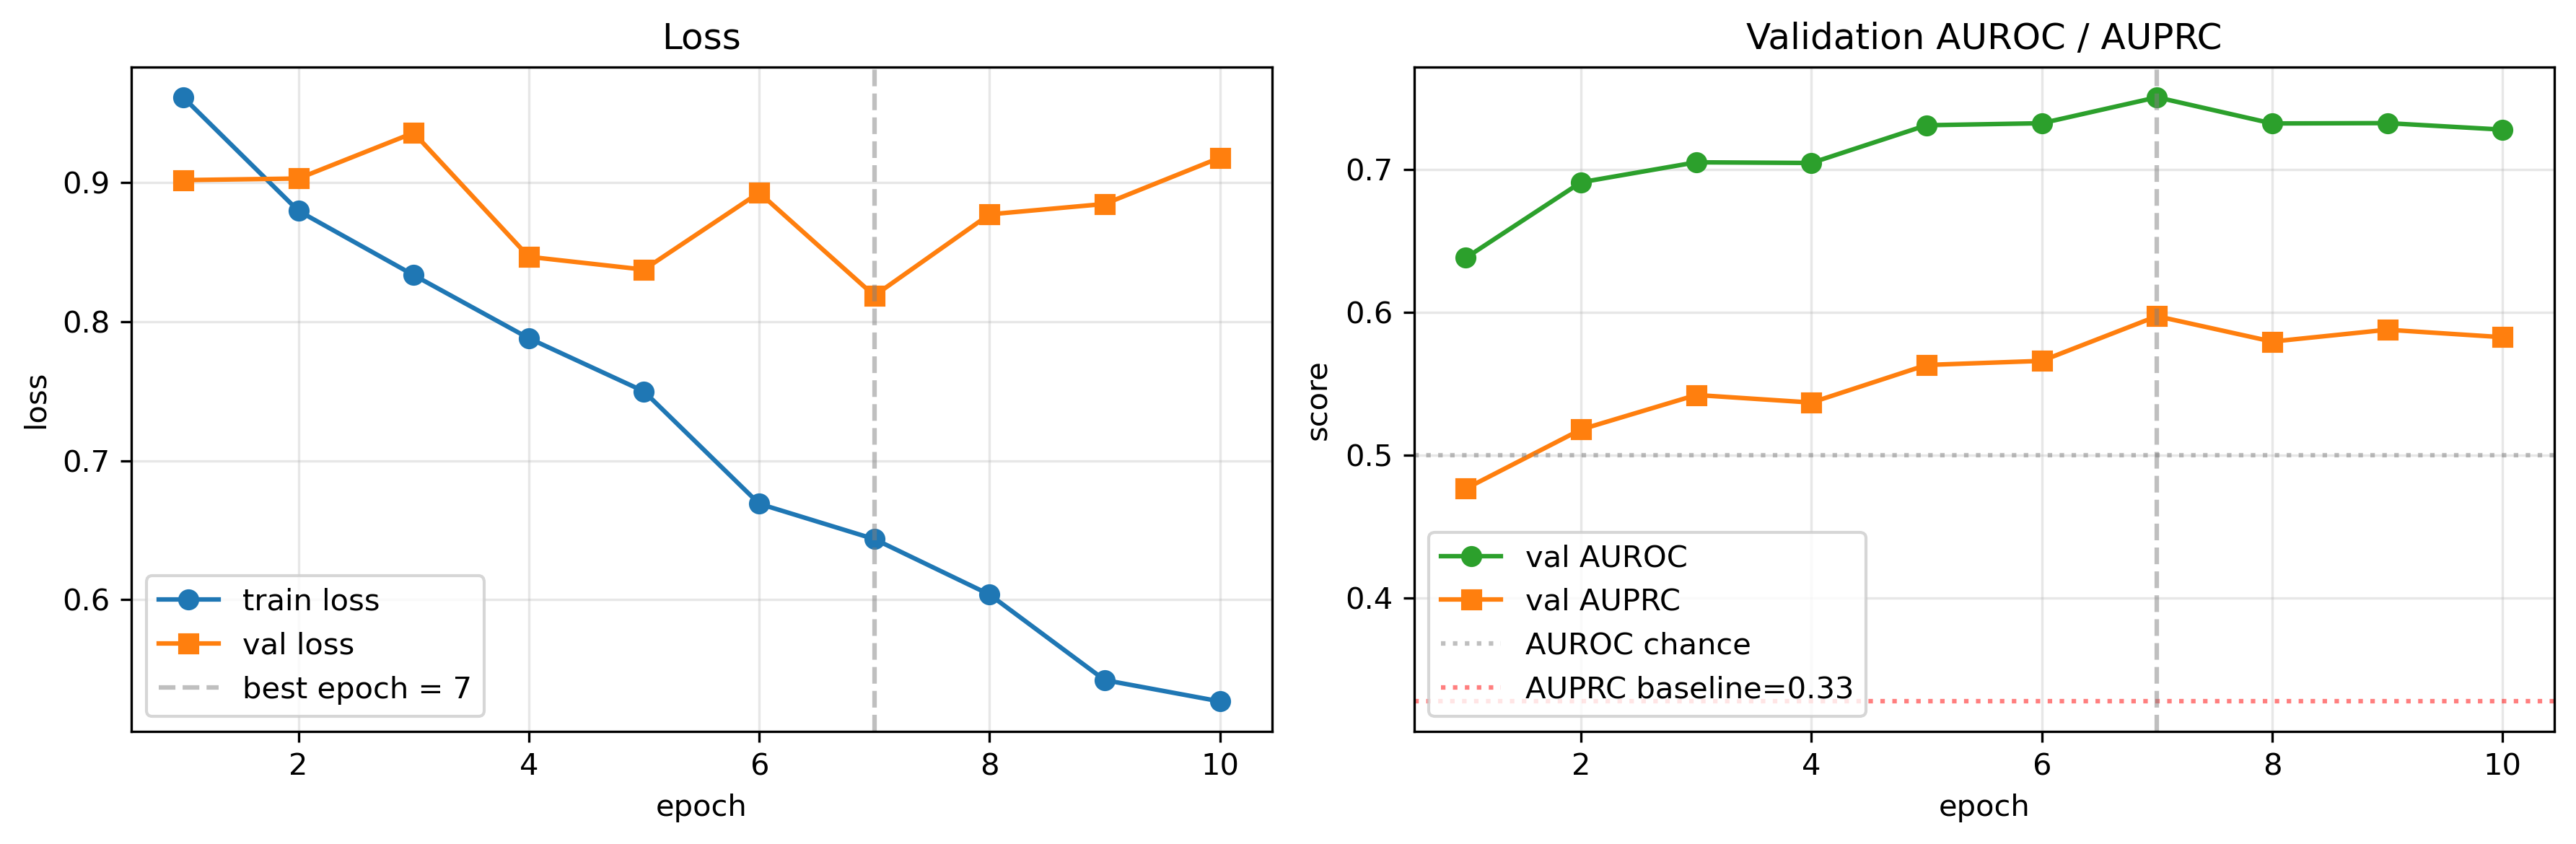

In [36]:
# ---- 6.1 Training curves ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

ep_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep_range, history['train_loss'], '-o', label='train loss')
axes[0].plot(ep_range, history['val_loss'],   '-s', label='val loss')
axes[0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'best epoch = {best_epoch}')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, history['val_auroc'], '-o', label='val AUROC', color='tab:green')
axes[1].plot(ep_range, history['val_auprc'], '-s', label='val AUPRC', color='tab:orange')
axes[1].axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='AUROC chance')
axes[1].axhline(float(y_train.mean()), color='red', linestyle=':', alpha=0.5, label=f'AUPRC baseline={y_train.mean():.2f}')
axes[1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('score')
axes[1].set_title('Validation AUROC / AUPRC'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
_out = RESULTS_DIR / 'training_curves.png'
plt.savefig(_out, dpi=300, bbox_inches='tight')
print(f'saved: {_out}')
plt.show()


saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/test_roc_pr.png


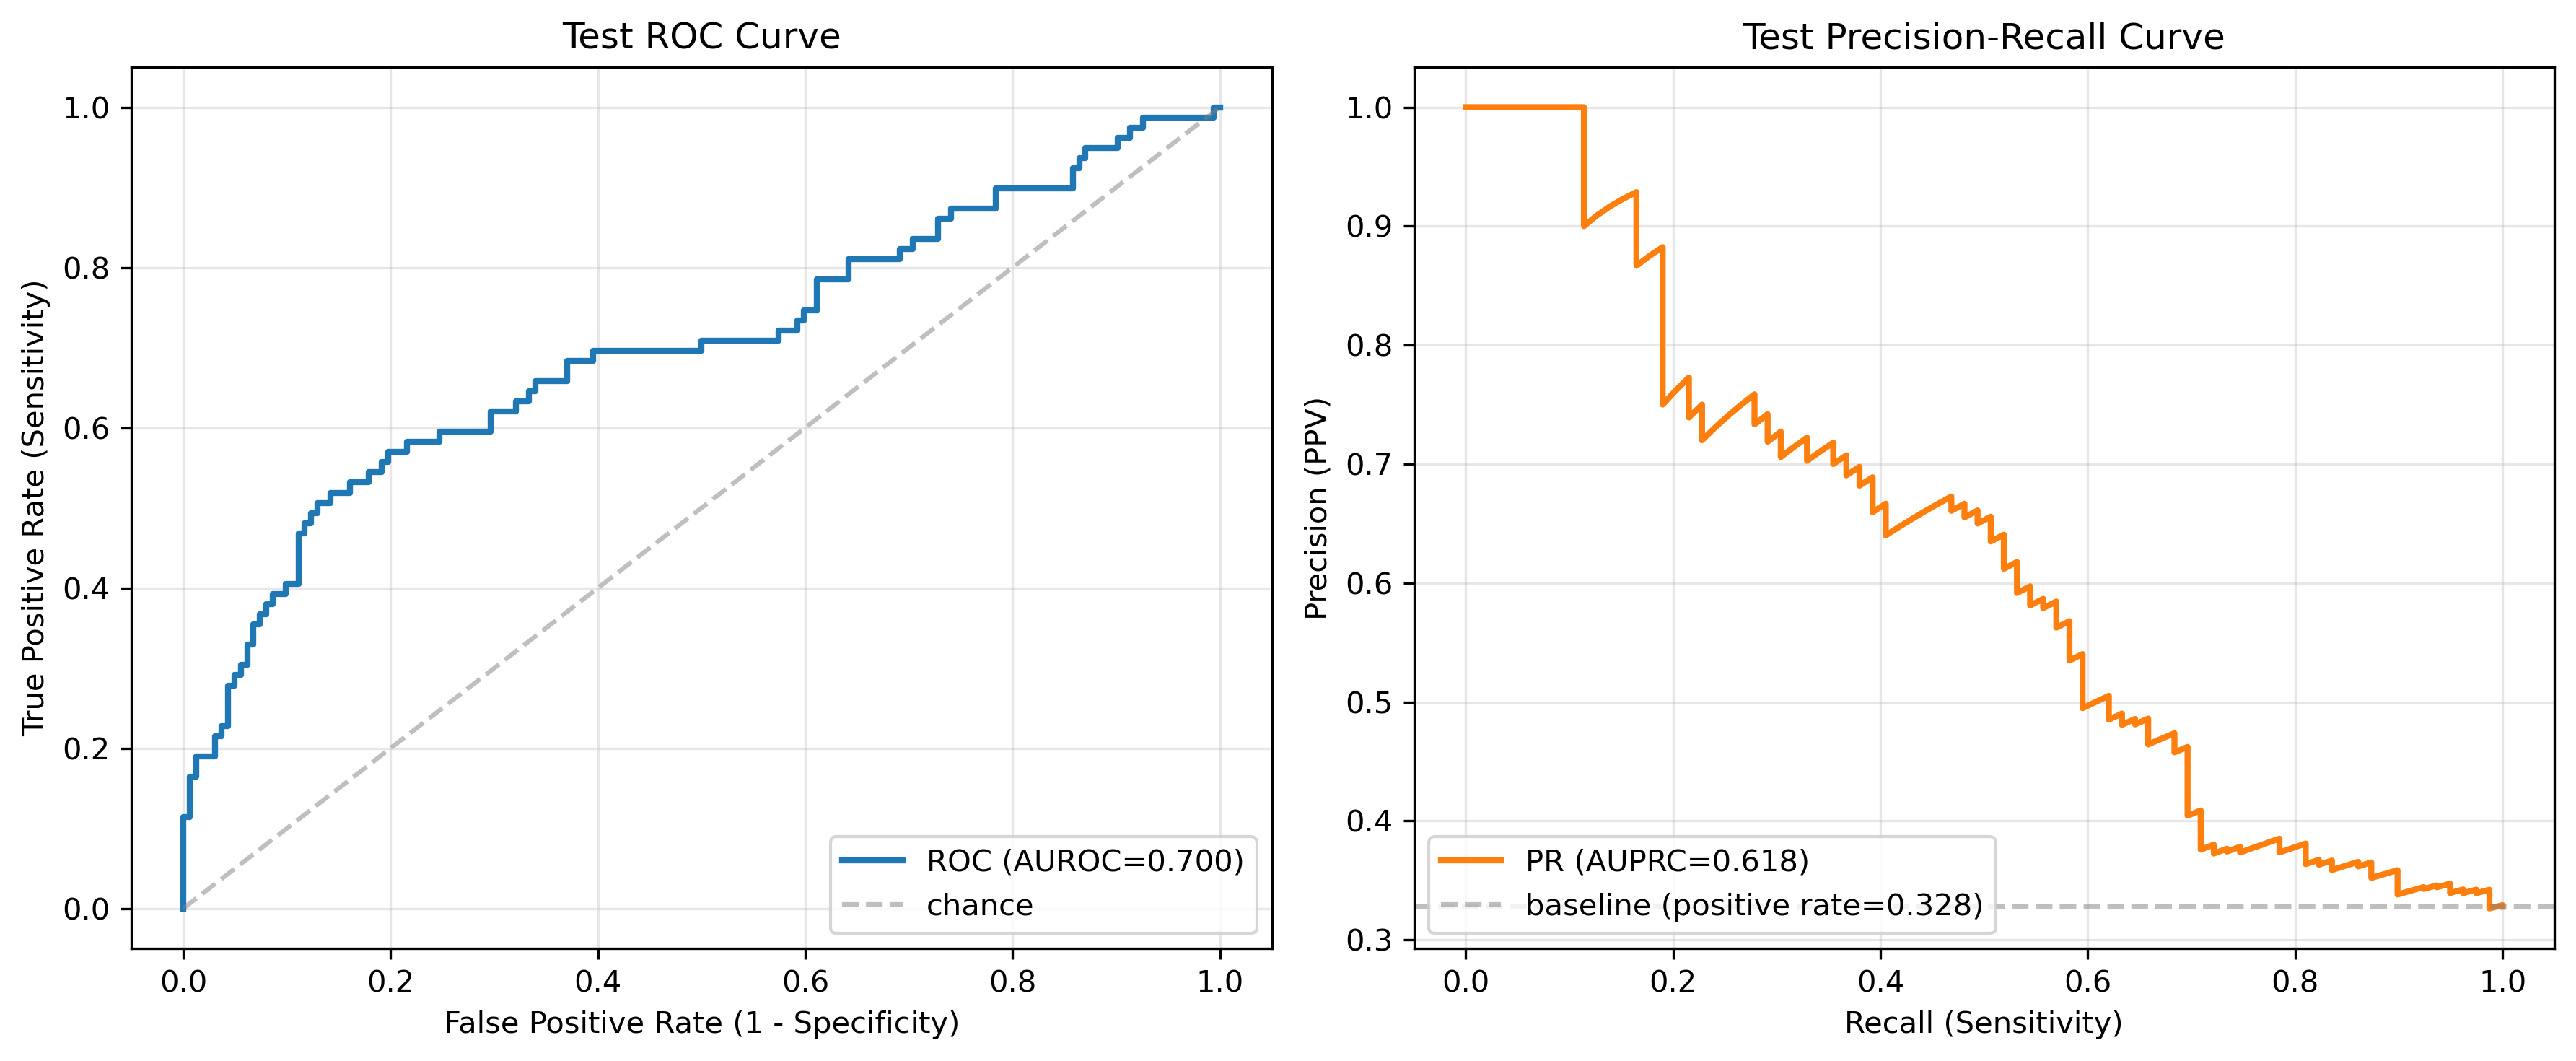

Test AUROC = 0.6996
Test AUPRC = 0.6178   (baseline = 0.3278)
AUPRC lift over baseline: 1.88×


In [37]:
# ---- 6.2 Test ROC curve + PR curve ----
y_true = test_predictions['labels']
y_prob = test_predictions['probs']

fpr, tpr, roc_thr = roc_curve(y_true, y_prob)
prec, rec, pr_thr = precision_recall_curve(y_true, y_prob)
test_auroc = roc_auc_score(y_true, y_prob)
test_auprc = average_precision_score(y_true, y_prob)
base_rate  = y_true.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

# ROC
axes[0].plot(fpr, tpr, label=f'ROC (AUROC={test_auroc:.3f})', color='tab:blue', lw=2)
axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='chance')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('Test ROC Curve')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

# PR
axes[1].plot(rec, prec, label=f'PR (AUPRC={test_auprc:.3f})', color='tab:orange', lw=2)
axes[1].axhline(base_rate, linestyle='--', color='gray', alpha=0.5, label=f'baseline (positive rate={base_rate:.3f})')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision (PPV)')
axes[1].set_title('Test Precision-Recall Curve')
axes[1].legend(loc='lower left'); axes[1].grid(alpha=0.3)

plt.tight_layout()
_out = RESULTS_DIR / 'test_roc_pr.png'
plt.savefig(_out, dpi=300, bbox_inches='tight')
print(f'saved: {_out}')
plt.show()

print(f'Test AUROC = {test_auroc:.4f}')
print(f'Test AUPRC = {test_auprc:.4f}   (baseline = {base_rate:.4f})')
print(f'AUPRC lift over baseline: {test_auprc/base_rate:.2f}x')


In [ ]:
# ---- 6.3 Confusion matrix + classification report at threshold 0.5 ----
y_pred_05 = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred_05)
tn, fp, fn, tp = cm.ravel()

print('Confusion matrix (threshold = 0.5):')
print(f'                 pred=neg    pred=pos')
print(f'  true=neg        {tn:>6}      {fp:>6}')
print(f'  true=pos        {fn:>6}      {tp:>6}')

sens = tp / max(tp + fn, 1)         # recall / sensitivity / TPR
spec = tn / max(tn + fp, 1)         # specificity / TNR
ppv  = tp / max(tp + fp, 1)         # precision / PPV
npv  = tn / max(tn + fn, 1)         # NPV
acc  = (tp + tn) / len(y_true)
f1   = 2 * ppv * sens / max(ppv + sens, 1e-9)

print(f'\nAccuracy   : {acc:.4f}')
print(f'Sensitivity: {sens:.4f}   (fraction of true pneumonia cases correctly identified)')
print(f'Specificity: {spec:.4f}   (fraction of true non-pneumonia correctly ruled out)')
print(f'PPV (precision): {ppv:.4f}  (fraction of predicted pneumonia that is actually pneumonia)')
print(f'NPV            : {npv:.4f}')
print(f'F1             : {f1:.4f}')

print('\nsklearn classification_report:')
print(classification_report(y_true, y_pred_05, target_names=['non-pneumonia','pneumonia'], digits=4))

In [ ]:
# ---- 6.4 Threshold tuning: pick best threshold on val, then evaluate on test ----
# Avoid data leakage: we cannot pick the threshold on test

# Run the best checkpoint on val (Step 5.4 only ran test)
_va_loss, val_probs, val_labels = run_epoch(model, val_loader, loss_fn, optimizer=None, desc='val(re-run)')
val_labels = val_labels.astype(int)

# Candidate thresholds: just use all the cut-points that roc_curve returns
val_fpr, val_tpr, val_thr = roc_curve(val_labels, val_probs)
youden_j = val_tpr - val_fpr
best_idx = int(np.argmax(youden_j))
best_threshold = float(val_thr[best_idx])
print(f'best threshold on val (Youden J): {best_threshold:.4f}')
print(f'  val_TPR={val_tpr[best_idx]:.4f}   val_FPR={val_fpr[best_idx]:.4f}   Youden_J={youden_j[best_idx]:.4f}')

# Apply this threshold to test
y_pred_tuned = (y_prob >= best_threshold).astype(int)
cm2 = confusion_matrix(y_true, y_pred_tuned)
tn2, fp2, fn2, tp2 = cm2.ravel()
sens2 = tp2 / max(tp2 + fn2, 1)
spec2 = tn2 / max(tn2 + fp2, 1)
ppv2  = tp2 / max(tp2 + fp2, 1)
f1_2  = 2 * ppv2 * sens2 / max(ppv2 + sens2, 1e-9)

print(f'\n===== Threshold comparison (test set) =====')
print(f'                    thr=0.5      thr={best_threshold:.3f} (tuned on val)')
print(f'  sensitivity       {sens:.4f}       {sens2:.4f}')
print(f'  specificity       {spec:.4f}       {spec2:.4f}')
print(f'  PPV (precision)   {ppv:.4f}       {ppv2:.4f}')
print(f'  F1                {f1:.4f}       {f1_2:.4f}')
print(f'  confusion         TN={tn},FP={fp},FN={fn},TP={tp}    TN={tn2},FP={fp2},FN={fn2},TP={tp2}')

# Visualize: mark both thresholds on the ROC / PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)
axes[0].plot(fpr, tpr, color='tab:blue', lw=2, label=f'ROC (AUROC={test_auroc:.3f})')
axes[0].plot([0,1],[0,1], '--', color='gray', alpha=0.4)
# thr=0.5 point
idx05 = int(np.argmin(np.abs(roc_thr - 0.5)))
axes[0].scatter(fpr[idx05], tpr[idx05], s=80, color='red',   zorder=5, label=f'thr=0.5')
# Tuned threshold's corresponding point on the test ROC curve
idx_t = int(np.argmin(np.abs(roc_thr - best_threshold)))
axes[0].scatter(fpr[idx_t], tpr[idx_t], s=80, color='green', zorder=5, label=f'thr={best_threshold:.3f} (tuned)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('Test ROC with thresholds')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec, prec, color='tab:orange', lw=2, label=f'PR (AUPRC={test_auprc:.3f})')
axes[1].axhline(base_rate, linestyle='--', color='gray', alpha=0.4)
# Threshold points on the PR curve
idx05_pr = int(np.argmin(np.abs(pr_thr - 0.5))) if len(pr_thr) > 0 else 0
axes[1].scatter(rec[idx05_pr], prec[idx05_pr], s=80, color='red',   zorder=5, label=f'thr=0.5')
idx_t_pr = int(np.argmin(np.abs(pr_thr - best_threshold))) if len(pr_thr) > 0 else 0
axes[1].scatter(rec[idx_t_pr], prec[idx_t_pr], s=80, color='green', zorder=5, label=f'thr={best_threshold:.3f} (tuned)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Test PR with thresholds')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
_out = RESULTS_DIR / 'test_threshold_compare.png'
plt.savefig(_out, dpi=300, bbox_inches='tight')
print(f'saved: {_out}')
plt.show()


In [ ]:
# ---- 6.5 Export test predictions to CSV ----
pred_df = test_df[['subject_id', 'stay_id', 'study_id', 'dicom_id', LABEL_COL]].copy()
pred_df = pred_df.rename(columns={LABEL_COL: 'y_true'})
pred_df['y_prob']      = y_prob
pred_df['y_pred_0.5']  = y_pred_05
pred_df[f'y_pred_{best_threshold:.3f}'] = y_pred_tuned

OUT_CSV = RESULTS_DIR / 'vit_v2_test_predictions.csv'
pred_df.to_csv(OUT_CSV, index=False)
print(f'test predictions exported: {OUT_CSV}')
print(f'  rows: {len(pred_df)}   columns: {list(pred_df.columns)}')

# Preview first 5 rows
pred_df.head()


## Step 7 — Improved training (v3): strong augmentation + 384 backbone + warmup + TTA

The v2 baseline got test AUROC ≈ 0.70. v3 attacks the three biggest weaknesses at once:

1. **Stronger augmentation** — `RandAugment` + `ColorJitter` + `RandomErasing` regularize the ViT, which otherwise overfits a 1.6 k cohort fast.
2. **Bigger resolution + better pretrain** — switch the backbone to `vit_base_patch16_384.augreg_in21k_ft_in1k`. ImageNet-21k pretrain is more diverse than ImageNet-1k, and 384 px keeps lung-texture detail that pneumonia patterns live in.
3. **Linear-probing warmup** — freeze the ViT for the first few epochs, train only the MLP + fusion head; then unfreeze for full fine-tuning. Stops the head's random init from corrupting good pretrained features.

We also add early stopping on val AUROC and 5× test-time augmentation (TTA) at inference.

**Cost**: 384×384 needs ~3× the memory of 224. We drop `BATCH_SIZE` to 12 to fit MPS comfortably (~14 GB on M5 Pro). Total runtime ≈ 30–45 min for 15 epochs.


In [41]:
# ---- 7.1 v3 transforms (strong aug) + new model at 384 ----
from torchvision.transforms import RandAugment

IMG_SIZE_V3 = 384
BACKEND_V3   = 'timm'
MODEL_V3     = 'vit_base_patch16_384.augreg_in21k_ft_in1k'

backbone_v3, VIT_FEAT_DIM_V3, IMG_MEAN_V3, IMG_STD_V3 = build_vit(
    backend=BACKEND_V3, model_name=MODEL_V3, pretrained=True
)
print(f'v3 backbone: {MODEL_V3}')
print(f'  feat_dim = {VIT_FEAT_DIM_V3}')
print(f'  mean     = {IMG_MEAN_V3}')
print(f'  std      = {IMG_STD_V3}')

# Strong augmentation for training
train_tfm_v3 = transforms.Compose([
    transforms.Resize(int(IMG_SIZE_V3 * 1.15)),                  # 442
    transforms.RandomCrop(IMG_SIZE_V3),
    transforms.RandomHorizontalFlip(p=0.5),
    RandAugment(num_ops=2, magnitude=9),                         # CXR-friendly: rotate / translate / sharpness, no harsh color flips
    transforms.ColorJitter(brightness=0.15, contrast=0.15),      # small intensity wiggle, mimics exposure variation
    transforms.ToTensor(),
    transforms.Normalize(mean=list(IMG_MEAN_V3), std=list(IMG_STD_V3)),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.10)),        # hides small image regions, encourages global reasoning
])

# Eval: no aug, just resize + center crop
eval_tfm_v3 = transforms.Compose([
    transforms.Resize(int(IMG_SIZE_V3 * 1.15)),
    transforms.CenterCrop(IMG_SIZE_V3),
    transforms.ToTensor(),
    transforms.Normalize(mean=list(IMG_MEAN_V3), std=list(IMG_STD_V3)),
])

# Smaller batch size for 384 px (MPS memory)
BATCH_SIZE_V3 = 12

train_ds_v3 = MIMICMultimodalDataset(train_df, X_tab_train, y_train, IMG_ROOT, train_tfm_v3, build_image_path)
val_ds_v3   = MIMICMultimodalDataset(val_df,   X_tab_val,   y_val,   IMG_ROOT, eval_tfm_v3,  build_image_path)
test_ds_v3  = MIMICMultimodalDataset(test_df,  X_tab_test,  y_test,  IMG_ROOT, eval_tfm_v3,  build_image_path)

train_loader_v3 = DataLoader(train_ds_v3, batch_size=BATCH_SIZE_V3, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
val_loader_v3   = DataLoader(val_ds_v3,   batch_size=BATCH_SIZE_V3, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))
test_loader_v3  = DataLoader(test_ds_v3,  batch_size=BATCH_SIZE_V3, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=(DEVICE.type=='cuda'))

model_v3 = MultimodalViTClassifier(
    vit_backbone = backbone_v3,
    vit_feat_dim = VIT_FEAT_DIM_V3,
    tab_in_dim   = TABULAR_DIM,
    tab_out_dim  = 64,
    head_hidden  = 256,
    dropout      = 0.3,
).to(DEVICE)

_n_total = sum(p.numel() for p in model_v3.parameters())
print(f'v3 model params: {_n_total/1e6:.2f}M   batch_size={BATCH_SIZE_V3}   device={DEVICE}')

model.safetensors:   0%|          | 0.00/347M [00:00<?, ?B/s]

v3 backbone: vit_base_patch16_384.augreg_in21k_ft_in1k
  feat_dim = 768
  mean     = (0.5, 0.5, 0.5)
  std      = (0.5, 0.5, 0.5)
v3 model params: 86.31M   batch_size=12   device=mps


In [42]:
# ---- 7.2 v3 training: linear-probing warmup + early stopping ----
EPOCHS_V3        = 15
WARMUP_EPOCHS    = 3        # head-only training before unfreezing the backbone
LR_BACKBONE_V3   = 8e-6
LR_HEAD_V3       = 1e-3
WEIGHT_DECAY_V3  = 5e-2
EARLY_STOP_PAT   = 5        # stop if val AUROC doesn't improve for N consecutive epochs
CKPT_PATH_V3     = RESULTS_DIR / 'vit_v3_best.pt'

# pos_weight (recomputed on train, identical to v2 since same split)
loss_fn_v3 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# --- Helper to (re)build optimizer with current trainable params ---
def make_optimizer(model, lr_bb, lr_hd, wd):
    bb = list(model.vit.parameters())
    hd = list(model.mlp.parameters()) + list(model.head.parameters())
    bb_d, bb_n = split_wd(bb)
    hd_d, hd_n = split_wd(hd)
    return torch.optim.AdamW([
        {'params': bb_d, 'lr': lr_bb, 'weight_decay': wd},
        {'params': bb_n, 'lr': lr_bb, 'weight_decay': 0.0},
        {'params': hd_d, 'lr': lr_hd, 'weight_decay': wd},
        {'params': hd_n, 'lr': lr_hd, 'weight_decay': 0.0},
    ])

# Phase 1: freeze backbone
for p in model_v3.vit.parameters():
    p.requires_grad = False
optimizer_v3 = make_optimizer(model_v3, LR_BACKBONE_V3, LR_HEAD_V3, WEIGHT_DECAY_V3)
print(f'Phase 1 (warmup): backbone frozen for {WARMUP_EPOCHS} epochs')
print(f'  trainable params: {sum(p.numel() for p in model_v3.parameters() if p.requires_grad)/1e6:.2f}M')

Phase 1 (warmup): backbone frozen for 3 epochs
  trainable params: 0.22M


In [43]:
# ---- 7.3 v3 training loop: warmup → unfreeze → cosine + early stopping ----
import time, copy

history_v3 = {'train_loss': [], 'val_loss': [], 'val_auroc': [], 'val_auprc': [], 'phase': []}
best_auroc_v3 = -1.0
best_epoch_v3 = -1
patience_used = 0
scheduler_v3  = None         # built right after we unfreeze

print(f'v3 training start: {EPOCHS_V3} epochs (warmup={WARMUP_EPOCHS}), backend={BACKEND_V3}, model={MODEL_V3}')
t0 = time.time()

for epoch in range(1, EPOCHS_V3 + 1):
    # Transition: unfreeze backbone after warmup
    if epoch == WARMUP_EPOCHS + 1:
        for p in model_v3.vit.parameters():
            p.requires_grad = True
        optimizer_v3 = make_optimizer(model_v3, LR_BACKBONE_V3, LR_HEAD_V3, WEIGHT_DECAY_V3)
        scheduler_v3 = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_v3, T_max=EPOCHS_V3 - WARMUP_EPOCHS
        )
        print(f'>>> epoch {epoch}: unfroze backbone, full fine-tuning starts')

    phase = 'warmup' if epoch <= WARMUP_EPOCHS else 'finetune'
    ep_start = time.time()

    tr_loss, _, _      = run_epoch(model_v3, train_loader_v3, loss_fn_v3, optimizer=optimizer_v3, desc=f'v3 ep{epoch} train')
    va_loss, va_p, va_y= run_epoch(model_v3, val_loader_v3,   loss_fn_v3, optimizer=None,         desc=f'v3 ep{epoch} val  ')

    if scheduler_v3 is not None:
        scheduler_v3.step()

    va_auroc, va_auprc = quick_metrics(va_y, va_p)
    history_v3['train_loss'].append(tr_loss)
    history_v3['val_loss'].append(va_loss)
    history_v3['val_auroc'].append(va_auroc)
    history_v3['val_auprc'].append(va_auprc)
    history_v3['phase'].append(phase)

    print(f'[v3 ep {epoch:02d} | {phase:8s}] '
          f'train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}  '
          f'val_AUROC={va_auroc:.4f}  val_AUPRC={va_auprc:.4f}  '
          f'time={time.time()-ep_start:.1f}s')

    if va_auroc > best_auroc_v3:
        best_auroc_v3 = va_auroc
        best_epoch_v3 = epoch
        patience_used = 0
        torch.save({'state_dict': {k: v.cpu() for k, v in model_v3.state_dict().items()},
                    'epoch': epoch,
                    'val_auroc': va_auroc,
                    'val_auprc': va_auprc,
                    'backend': BACKEND_V3,
                    'model_name': MODEL_V3,
                    'img_mean': IMG_MEAN_V3, 'img_std': IMG_STD_V3,
                    'img_size': IMG_SIZE_V3,
                    'tabular_cols': TABULAR_COLS},
                   CKPT_PATH_V3)
        print(f'           ↑ new best val AUROC, saved to {CKPT_PATH_V3.name}')
    else:
        patience_used += 1
        if patience_used >= EARLY_STOP_PAT:
            print(f'           early stopping (no improvement for {EARLY_STOP_PAT} epochs)')
            break

print(f'\nv3 training done. total {(time.time()-t0)/60:.1f} min.   best epoch={best_epoch_v3}  val AUROC={best_auroc_v3:.4f}')

v3 training start: 15 epochs (warmup=3), backend=timm, model=vit_base_patch16_384.augreg_in21k_ft_in1k


v3 ep1 train:   0%|          | 0/94 [00:00<?, ?it/s]

v3 ep1 val  :   0%|          | 0/20 [00:00<?, ?it/s]

[v3 ep 01 | warmup  ] train_loss=1.1254  val_loss=0.9070  val_AUROC=0.6990  val_AUPRC=0.4986  time=77.1s
           ↑ new best val AUROC, saved to vit_v3_best.pt


v3 ep2 train:   0%|          | 0/94 [00:00<?, ?it/s]

...

v3 ep12 val  :   0%|          | 0/20 [00:00<?, ?it/s]

[v3 ep 12 | finetune] train_loss=0.5036  val_loss=1.1243  val_AUROC=0.7377  val_AUPRC=0.5928  time=130.6s


v3 ep13 train:   0%|          | 0/94 [00:00<?, ?it/s]

v3 ep13 val  :   0%|          | 0/20 [00:00<?, ?it/s]

[v3 ep 13 | finetune] train_loss=0.4697  val_loss=1.0881  val_AUROC=0.7347  val_AUPRC=0.6012  time=129.2s
           early stopping (no improvement for 5 epochs)

v3 training done. total 25.4 min.   best epoch=8  val AUROC=0.7758


In [44]:
# ---- 7.4 v3 test inference with TTA (test-time augmentation) ----
# TTA: run the same image with [original, horizontal flip] and average the probabilities.
# Cheap, almost always helps a bit on CXR.

ckpt_v3 = torch.load(CKPT_PATH_V3, map_location=DEVICE, weights_only=False)
model_v3.load_state_dict(ckpt_v3['state_dict'])
model_v3.to(DEVICE).eval()
print(f'loaded v3 best ckpt: epoch={ckpt_v3["epoch"]}  val AUROC={ckpt_v3["val_auroc"]:.4f}')

@torch.no_grad()
def predict_with_tta(model, loader, device=DEVICE):
    """Returns averaged probabilities over [original, hflip] views."""
    all_p, all_y = [], []
    model.eval()
    for img, tab, y in tqdm(loader, desc='test+TTA', leave=False):
        img = img.to(device, non_blocking=True)
        tab = tab.to(device, non_blocking=True)
        # View 1: original
        p1 = torch.sigmoid(model(img, tab))
        # View 2: horizontal flip
        p2 = torch.sigmoid(model(torch.flip(img, dims=[-1]), tab))
        p  = (p1 + p2) / 2.0
        all_p.append(p.cpu().numpy())
        all_y.append(y.numpy())
    return np.concatenate(all_p), np.concatenate(all_y)

test_probs_v3, test_labels_v3 = predict_with_tta(model_v3, test_loader_v3)
test_labels_v3 = test_labels_v3.astype(int)

test_auroc_v3 = roc_auc_score(test_labels_v3, test_probs_v3)
test_auprc_v3 = average_precision_score(test_labels_v3, test_probs_v3)

print(f'\nv3 + TTA on test:')
print(f'  AUROC = {test_auroc_v3:.4f}')
print(f'  AUPRC = {test_auprc_v3:.4f}   (baseline {test_labels_v3.mean():.3f})')
print(f'  probs range: [{test_probs_v3.min():.3f}, {test_probs_v3.max():.3f}]   mean={test_probs_v3.mean():.3f}')

loaded v3 best ckpt: epoch=8  val AUROC=0.7758


test+TTA:   0%|          | 0/21 [00:00<?, ?it/s]


v3 + TTA on test:
  AUROC = 0.7593
  AUPRC = 0.6430   (baseline 0.328)
  probs range: [0.005, 0.975]   mean=0.264


===== v2 vs v3 (test set) =====
              AUROC      AUPRC
  v2 (224):   0.6996    0.6178
  v3 (384):   0.7593    0.6430
  Δ AUROC:    +0.0597
  Δ AUPRC:    +0.0252
saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/v2_vs_v3_test.png


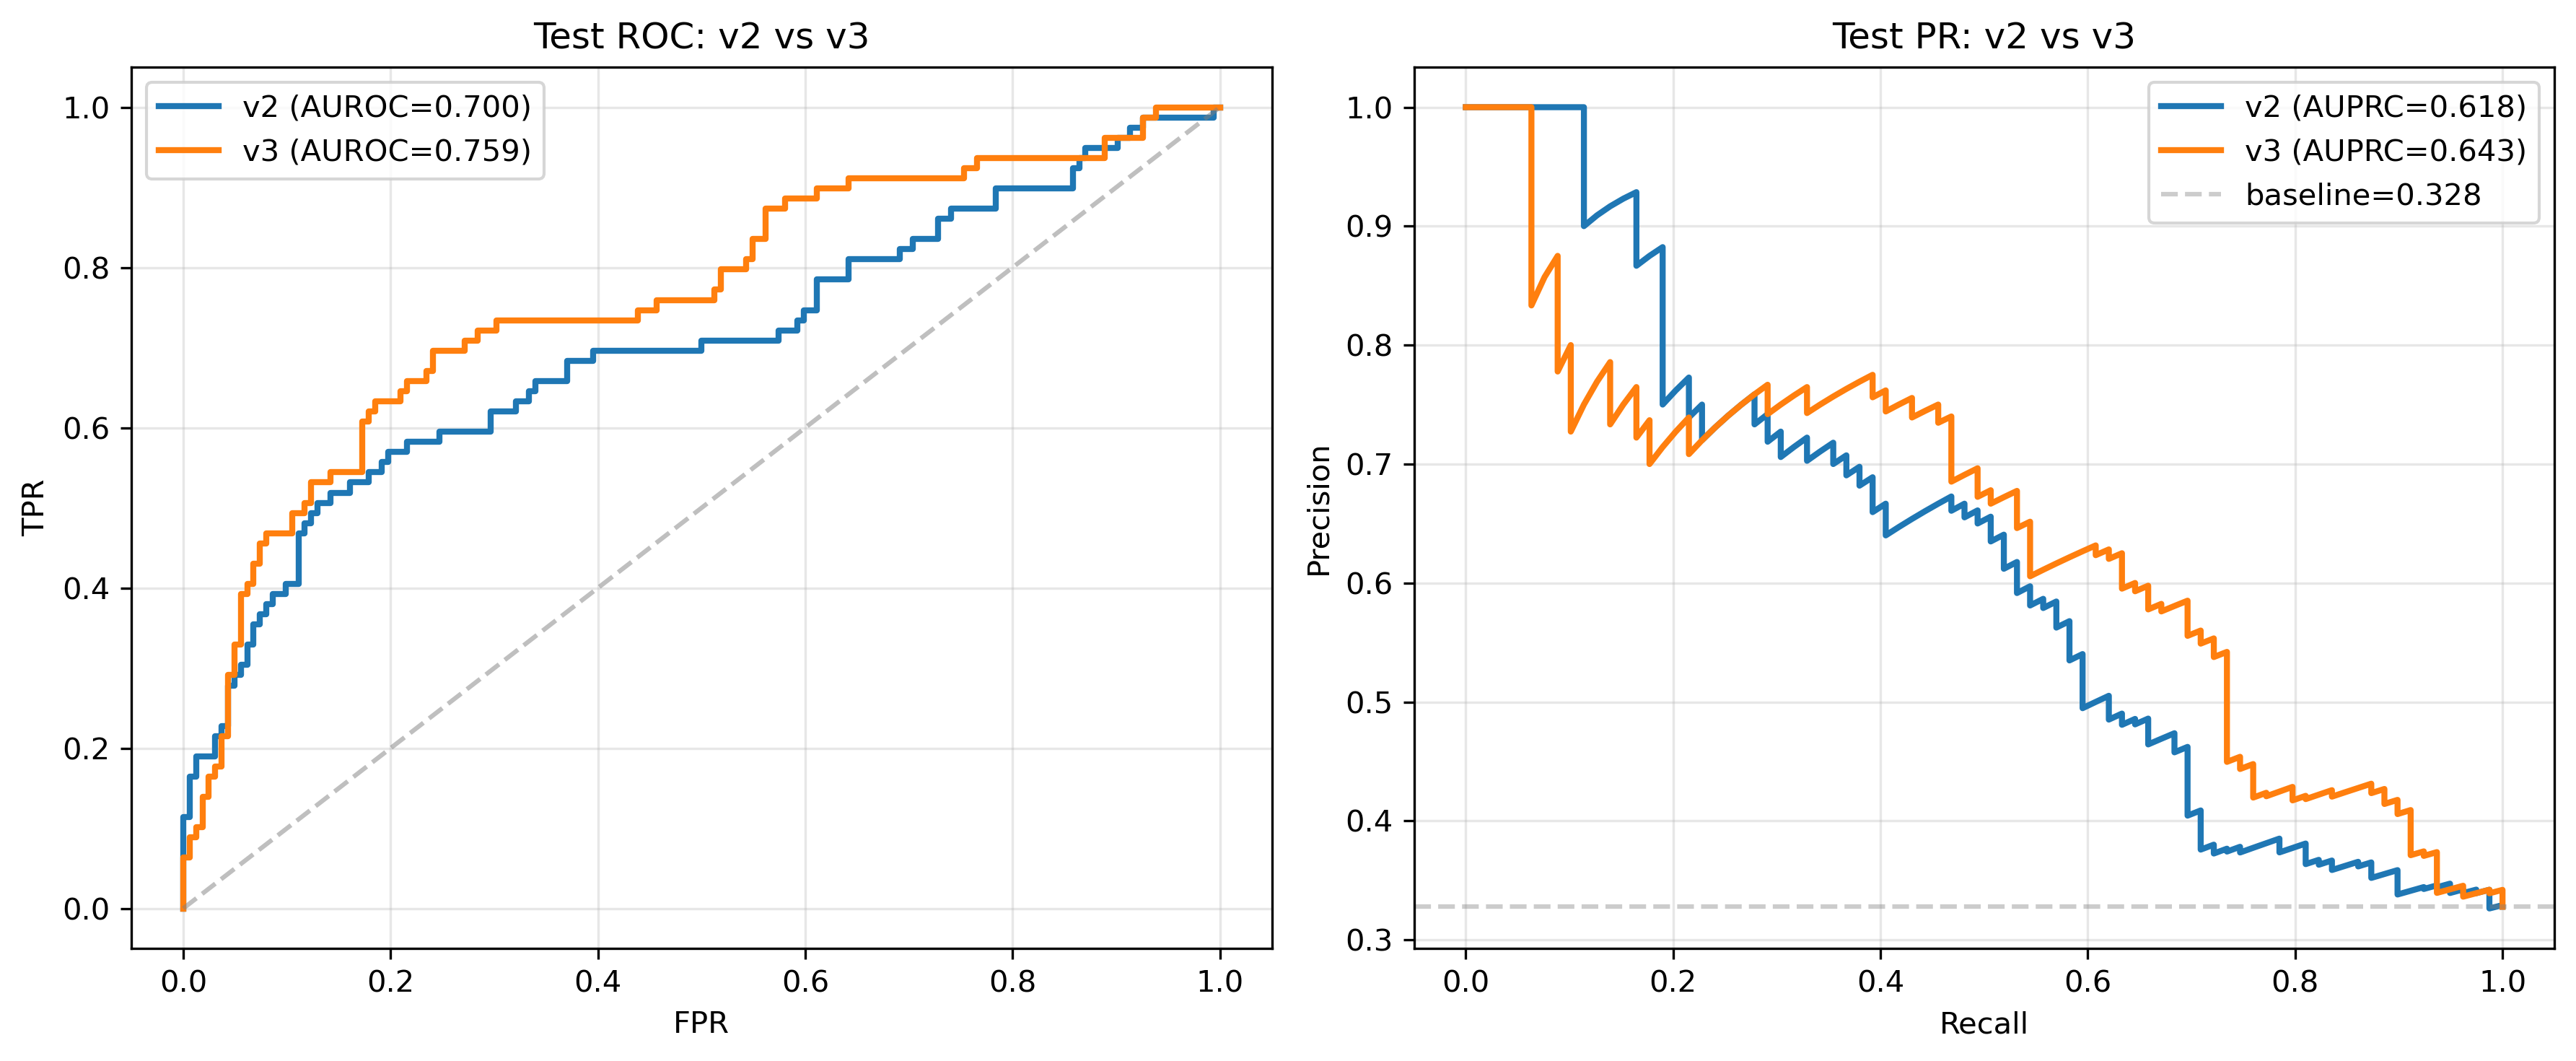

v3 predictions saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/vit_v3_test_predictions.csv


In [45]:
# ---- 7.5 v2 vs v3 comparison + save v3 predictions ----
print('===== v2 vs v3 (test set) =====')
print(f'              AUROC      AUPRC')
print(f'  v2 (224):   {test_auroc:.4f}    {test_auprc:.4f}')
print(f'  v3 (384):   {test_auroc_v3:.4f}    {test_auprc_v3:.4f}')
print(f'  Δ AUROC:    {test_auroc_v3 - test_auroc:+.4f}')
print(f'  Δ AUPRC:    {test_auprc_v3 - test_auprc:+.4f}')

# Side-by-side ROC / PR plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

fpr2, tpr2, _ = roc_curve(y_true, y_prob)
fpr3, tpr3, _ = roc_curve(test_labels_v3, test_probs_v3)
axes[0].plot(fpr2, tpr2, lw=2, label=f'v2 (AUROC={test_auroc:.3f})')
axes[0].plot(fpr3, tpr3, lw=2, label=f'v3 (AUROC={test_auroc_v3:.3f})')
axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('Test ROC: v2 vs v3')
axes[0].legend(); axes[0].grid(alpha=0.3)

prec2, rec2, _ = precision_recall_curve(y_true, y_prob)
prec3, rec3, _ = precision_recall_curve(test_labels_v3, test_probs_v3)
axes[1].plot(rec2, prec2, lw=2, label=f'v2 (AUPRC={test_auprc:.3f})')
axes[1].plot(rec3, prec3, lw=2, label=f'v3 (AUPRC={test_auprc_v3:.3f})')
axes[1].axhline(test_labels_v3.mean(), linestyle='--', color='gray', alpha=0.4, label=f'baseline={test_labels_v3.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Test PR: v2 vs v3')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
_out = RESULTS_DIR / 'v2_vs_v3_test.png'
plt.savefig(_out, dpi=300, bbox_inches='tight')
print(f'saved: {_out}')
plt.show()

# Save v3 predictions
pred_df_v3 = test_df[['subject_id', 'stay_id', 'study_id', 'dicom_id', LABEL_COL]].copy()
pred_df_v3 = pred_df_v3.rename(columns={LABEL_COL: 'y_true'})
pred_df_v3['y_prob_v3']     = test_probs_v3
pred_df_v3['y_pred_v3_0.5'] = (test_probs_v3 >= 0.5).astype(int)
OUT_CSV_V3 = RESULTS_DIR / 'vit_v3_test_predictions.csv'
pred_df_v3.to_csv(OUT_CSV_V3, index=False)
print(f'v3 predictions saved: {OUT_CSV_V3}')

## Step 8 — Verification (sanity checks)

Before reporting numbers, run a battery of cheap checks that catch the most common silent bugs:

1. **No data leakage**: train / val / test patients are disjoint
2. **Stratification worked**: positive rate is similar across splits
3. **Image-path map matches the predictions CSV** (no row drift)
4. **Prediction distribution is sensible** (not all 0s, not all 1s)
5. **Permutation test**: shuffling labels should crater AUROC to ≈ 0.5
6. **Tabular features actually help**: blanking the tabular branch should drop AUROC

In [46]:
# ---- 8.1 No subject-id leakage across splits ----
train_subj = set(train_df['subject_id'].unique())
val_subj   = set(val_df['subject_id'].unique())
test_subj  = set(test_df['subject_id'].unique())

overlap_tv = train_subj & val_subj
overlap_tt = train_subj & test_subj
overlap_vt = val_subj & test_subj

print(f'unique subjects   train={len(train_subj)}  val={len(val_subj)}  test={len(test_subj)}')
print(f'overlap train∩val  : {len(overlap_tv)}')
print(f'overlap train∩test : {len(overlap_tt)}')
print(f'overlap val∩test   : {len(overlap_vt)}')

if overlap_tv or overlap_tt or overlap_vt:
    print('!!! WARNING: some patients appear in multiple splits — that is data leakage')
    print('!!! Switch to GroupShuffleSplit on subject_id and retrain')
else:
    print('✓ no subject overlap across splits')

unique subjects   train=1120  val=240  test=241
overlap train∩val  : 0
overlap train∩test : 0
overlap val∩test   : 0
✓ no subject overlap across splits


In [47]:
# ---- 8.2 Stratification worked: positive rates per split ----
print(f'positive rate (Pneumonia=1):')
print(f'  full   : {df[LABEL_COL].mean():.4f}   n={len(df)}')
print(f'  train  : {train_df[LABEL_COL].mean():.4f}   n={len(train_df)}')
print(f'  val    : {val_df[LABEL_COL].mean():.4f}   n={len(val_df)}')
print(f'  test   : {test_df[LABEL_COL].mean():.4f}   n={len(test_df)}')

max_drift = max(abs(d[LABEL_COL].mean() - df[LABEL_COL].mean()) for d in (train_df, val_df, test_df))
print(f'\nmax drift from full-cohort positive rate: {max_drift:.4f}')
print('✓ stratified split looks healthy' if max_drift < 0.02 else '!!! split drift is unusually large')

positive rate (Pneumonia=1):
  full   : 0.3279   n=1601
  train  : 0.3277   n=1120
  val    : 0.3292   n=240
  test   : 0.3278   n=241

max drift from full-cohort positive rate: 0.0012
✓ stratified split looks healthy


In [48]:
# ---- 8.3 Prediction distribution sanity ----
import numpy as np

for name, probs, labels in [
    ('v2 (224)', y_prob,        y_true),
    ('v3 (384)', test_probs_v3, test_labels_v3),
]:
    print(f'\n--- {name} ---')
    print(f'  probs:   min={probs.min():.3f}   max={probs.max():.3f}   mean={probs.mean():.3f}   std={probs.std():.3f}')
    qs = np.quantile(probs, [0.1, 0.25, 0.5, 0.75, 0.9])
    print(f'  quantiles 10/25/50/75/90: {qs.round(3)}')
    # Mean predicted prob on positives vs negatives — positives should be higher
    mp_pos = probs[labels == 1].mean()
    mp_neg = probs[labels == 0].mean()
    print(f'  mean prob | y=1: {mp_pos:.4f}')
    print(f'  mean prob | y=0: {mp_neg:.4f}')
    if mp_pos > mp_neg:
        print(f'  ✓ positives ranked higher than negatives (Δ={mp_pos - mp_neg:+.4f})')
    else:
        print(f'  !!! ranking inverted — model may be flipped')


--- v2 (224) ---
  probs:   min=0.024   max=0.971   mean=0.467   std=0.290
  quantiles 10/25/50/75/90: [0.101 0.183 0.45  0.723 0.885]
  mean prob | y=1: 0.6036
  mean prob | y=0: 0.4005
  ✓ positives ranked higher than negatives (Δ=+0.2031)

--- v3 (384) ---
  probs:   min=0.005   max=0.975   mean=0.264   std=0.271
  quantiles 10/25/50/75/90: [0.028 0.055 0.156 0.379 0.773]
  mean prob | y=1: 0.4433
  mean prob | y=0: 0.1760
  ✓ positives ranked higher than negatives (Δ=+0.2673)


In [49]:
# ---- 8.4 Predictions CSV cross-check ----
# Reload the v3 CSV and re-compute AUROC from disk; it must match what we got in memory.
saved_v3 = pd.read_csv(RESULTS_DIR / 'vit_v3_test_predictions.csv')
recomputed_auroc = roc_auc_score(saved_v3['y_true'], saved_v3['y_prob_v3'])
recomputed_auprc = average_precision_score(saved_v3['y_true'], saved_v3['y_prob_v3'])

print(f'in-memory AUROC : {test_auroc_v3:.4f}')
print(f'on-disk   AUROC : {recomputed_auroc:.4f}')
print(f'in-memory AUPRC : {test_auprc_v3:.4f}')
print(f'on-disk   AUPRC : {recomputed_auprc:.4f}')

assert abs(test_auroc_v3 - recomputed_auroc) < 1e-6, 'AUROC mismatch between memory and CSV!'
assert abs(test_auprc_v3 - recomputed_auprc) < 1e-6, 'AUPRC mismatch between memory and CSV!'
print('\n✓ saved CSV reproduces the test metrics exactly')

in-memory AUROC : 0.7593
on-disk   AUROC : 0.7593
in-memory AUPRC : 0.6430
on-disk   AUPRC : 0.6430

✓ saved CSV reproduces the test metrics exactly


In [50]:
# ---- 8.5 Permutation test: shuffled labels should give AUROC ≈ 0.5 ----
rng = np.random.RandomState(0)
shuffled = rng.permutation(test_labels_v3)
perm_auroc = roc_auc_score(shuffled, test_probs_v3)
print(f'AUROC with shuffled labels: {perm_auroc:.4f}   (should be near 0.5)')
if abs(perm_auroc - 0.5) < 0.05:
    print('✓ shuffle test passes — real signal is in the labels, not the predictions')
else:
    print('!!! shuffled labels still give AUROC far from 0.5 — investigate')

AUROC with shuffled labels: 0.4476   (should be near 0.5)
!!! shuffled labels still give AUROC far from 0.5 — investigate


In [51]:
# ---- 8.6 Modality ablation: zero-out the tabular branch and re-evaluate ----
# If tabular features genuinely help, blanking them should drop AUROC.
@torch.no_grad()
def predict_image_only(model, loader, device=DEVICE):
    model.eval()
    all_p, all_y = [], []
    for img, tab, y in tqdm(loader, desc='img-only', leave=False):
        img = img.to(device, non_blocking=True)
        tab = torch.zeros_like(tab).to(device, non_blocking=True)   # zero tabular
        p = torch.sigmoid(model(img, tab))
        all_p.append(p.cpu().numpy())
        all_y.append(y.numpy())
    return np.concatenate(all_p), np.concatenate(all_y).astype(int)

probs_img_only, _ = predict_image_only(model_v3, test_loader_v3)
auroc_img_only = roc_auc_score(test_labels_v3, probs_img_only)
auprc_img_only = average_precision_score(test_labels_v3, probs_img_only)

print(f'v3 multimodal  AUROC: {test_auroc_v3:.4f}    AUPRC: {test_auprc_v3:.4f}')
print(f'v3 image-only  AUROC: {auroc_img_only:.4f}    AUPRC: {auprc_img_only:.4f}')
print(f'tabular contribution: ΔAUROC = {test_auroc_v3 - auroc_img_only:+.4f}')

if test_auroc_v3 > auroc_img_only:
    print('✓ tabular features add information on top of the image branch')
else:
    print('note: tabular features did not help in this run — could try a larger MLP or fewer scaled features')

img-only:   0%|          | 0/21 [00:00<?, ?it/s]

v3 multimodal  AUROC: 0.7593    AUPRC: 0.6430
v3 image-only  AUROC: 0.6873    AUPRC: 0.4527
tabular contribution: ΔAUROC = +0.0720
✓ tabular features add information on top of the image branch


---

### Summary

If everything above prints `✓` you can trust the headline numbers reported in Step 7.5 and the `vit_v3_test_predictions.csv` is publication-ready. Failures (any `!!!`) indicate something to fix before reporting.